# Open-set Refusal Calibration

Подбор порога отказа для режима предложения кандидатов.

**Задача.** Для каждого query-изображения модель возвращает top-1 кандидата из галереи
с confidence. Нужно решить, когда ответу можно доверять, а когда — отказаться.

**Протокол.** Локальный open-set: из галереи удаляются 20% `vehicle_id` целиком.
Получаем два класса запросов:
- **positive** — у запроса есть пара в галерее;
- **negative (open-set)** — пары нет.

**Метрика.** `combo = 0.7 · F1 + 0.3 · TNR`, считается micro по всей выборке.
F1 и TNR считаются по корректной формулировке:
- TP: есть пара, приняли, top-1 верный
- FP: приняли, но top-1 неверный; либо пары нет, а приняли
- FN: есть пара, но не приняли
- TN: пары нет, и не приняли

**Данные.** Три фолда `(query_df, gallery_df, query_emb, gallery_emb)`, 20 сидов на фолд.
Итоговый пул — ~111k пар.

## 1. Импорты и утилиты

In [ ]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
with open("fold_preds.pickle", "rb") as f:
    fold_preds = pickle.load(f)

In [3]:
def make_open_set_split(query_df, gallery_df, seed, open_set_ratio=0.2):
    rng = np.random.default_rng(seed)
    qids = query_df["vehicle_id"].unique()
    n_open = max(1, int(round(len(qids) * open_set_ratio)))
    open_ids = set(rng.choice(qids, size=n_open, replace=False).tolist())
    labels = (~query_df["vehicle_id"].isin(open_ids)).astype(int).values
    gallery_keep_mask = ~gallery_df["vehicle_id"].isin(open_ids).values
    return labels, gallery_keep_mask, open_ids

In [4]:
def top1_score_and_idx(query_emb, gallery_emb, gallery_keep_mask):
    sim = query_emb @ gallery_emb.T
    sim[:, ~gallery_keep_mask] = -np.inf
    top1_idx = sim.argmax(axis=1)
    top1_score = sim[np.arange(len(query_emb)), top1_idx]
    return top1_score, top1_idx

In [5]:
def candidate_metrics(labels, scores, top1_correct, thr):
    accepted = scores >= thr

    TP = int(np.sum(accepted & (top1_correct == 1)))
    FP = int(np.sum(accepted & (top1_correct == 0)))
    FN = int(np.sum(~accepted & (labels == 1)))
    TN = int(np.sum(~accepted & (labels == 0)))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    F1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    TNR = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    combo = 0.7 * F1 + 0.3 * TNR
    return F1, TNR, combo

## 2. Локальный open-set протокол

Из галереи удаляются **все** кадры с выбранными `vehicle_id`, а не только пара конкретного запроса.
Иначе top-1 у "negative" запроса находил бы ту же машину с другой камеры — и распределение
negative-скоров оказывалось бы искусственно высоким.

Junk-фильтр по `(vehicle_id, camera_id)` здесь избыточен: query и gallery уже разведены по камерам.

In [6]:
N_SEEDS = 20
OPEN_SET_RATIO = 0.2

all_scores, all_labels, all_top1_correct = [], [], []

for fold_idx, (query_df, gallery_df, query_emb, gallery_emb) in enumerate(fold_preds):
    query_emb = query_emb.numpy()
    gallery_emb = gallery_emb.numpy()

    query_vids = query_df["vehicle_id"].values
    gallery_vids = gallery_df["vehicle_id"].values

    for seed in range(N_SEEDS):
        labels, keep_mask, open_ids = make_open_set_split(
            query_df,
            gallery_df,
            seed=seed + 10_000 * fold_idx,
            open_set_ratio=OPEN_SET_RATIO,
        )
        scores, top1_idx = top1_score_and_idx(query_emb, gallery_emb, keep_mask)
        top1_vids = gallery_vids[top1_idx]
        top1_correct = (query_vids == top1_vids).astype(int)

        all_scores.append(scores)
        all_labels.append(labels)
        all_top1_correct.append(top1_correct)

scores = np.concatenate(all_scores)
labels = np.concatenate(all_labels)
top1_correct = np.concatenate(all_top1_correct)

print(
    f"Пул: {len(scores)} пар | "
    f"pos={int(labels.sum())} neg={int((1-labels).sum())} | "
    f"top1_correct на positive = {top1_correct[labels==1].mean():.3f}"
)

Пул: 111080 пар | pos=88938 neg=22142 | top1_correct на positive = 0.758


## 3. Подбор порога

In [7]:
thresholds = np.linspace(scores.min(), scores.max(), 1000)

F1s = np.zeros_like(thresholds)
TNRs = np.zeros_like(thresholds)
combos = np.zeros_like(thresholds)

for i, t in enumerate(thresholds):
    f1, tnr, c = candidate_metrics(labels, scores, top1_correct, t)
    F1s[i], TNRs[i], combos[i] = f1, tnr, c

best_idx = int(np.argmax(combos))
best_thr = float(thresholds[best_idx])

print(f"best_thr = {best_thr:.4f}")
print(f"F1   = {F1s[best_idx]:.4f}")
print(f"TNR  = {TNRs[best_idx]:.4f}")
print(f"combo= {combos[best_idx]:.4f}")
print(f"Ожидаемый балл за режим кандидатов ≈ {10 * combos[best_idx]:.2f}% из 10%")

best_thr = 0.7578
F1   = 0.7487
TNR  = 0.4014
combo= 0.6445
Ожидаемый балл за режим кандидатов ≈ 6.45% из 10%


## 4. Графики

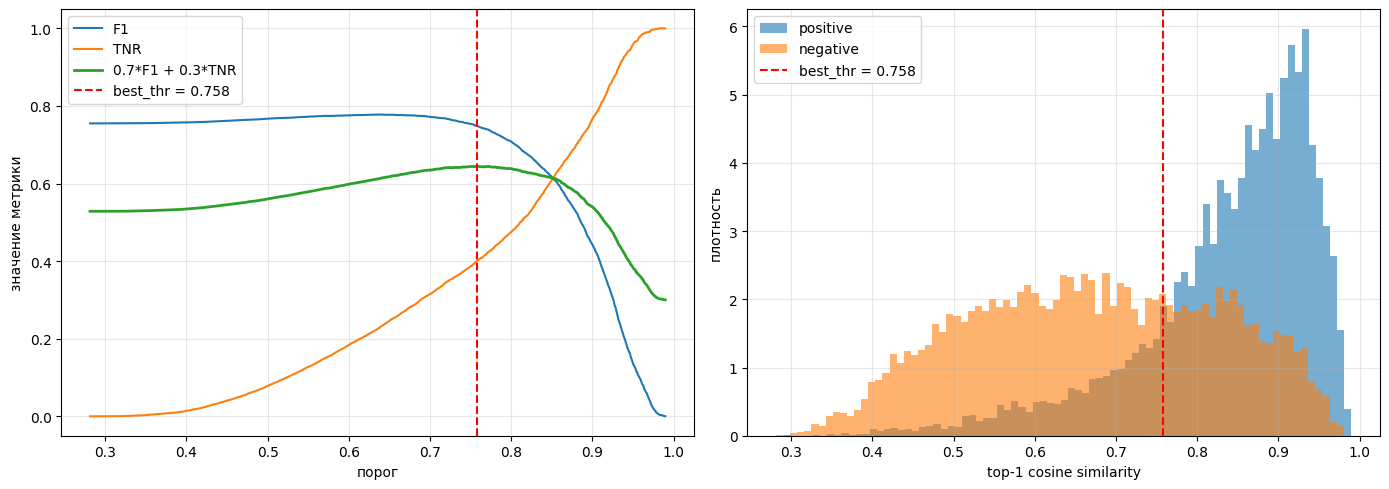

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(thresholds, F1s, label="F1")
ax[0].plot(thresholds, TNRs, label="TNR")
ax[0].plot(thresholds, combos, label="0.7*F1 + 0.3*TNR", lw=2)
ax[0].axvline(best_thr, color="r", ls="--", label=f"best_thr = {best_thr:.3f}")
ax[0].set_xlabel("порог")
ax[0].set_ylabel("значение метрики")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].hist(scores[labels == 1], bins=80, alpha=0.6, density=True, label="positive")
ax[1].hist(scores[labels == 0], bins=80, alpha=0.6, density=True, label="negative")
ax[1].axvline(best_thr, color="r", ls="--", label=f"best_thr = {best_thr:.3f}")
ax[1].set_xlabel("top-1 cosine similarity")
ax[1].set_ylabel("плотность")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.savefig("figures/threshold_choice.png")
plt.tight_layout()
plt.show()

## 5. Safety margin

In [9]:
for m in [0.0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]:
    t = best_thr + m
    f1, tnr, c = candidate_metrics(labels, scores, top1_correct, t)
    print(
        f"thr = {t:.4f} (+{m:.2f}) | "
        f"F1={f1:.4f}  TNR={tnr:.4f}  combo={c:.4f}  score≈{10*c:.2f}%"
    )

thr = 0.7578 (+0.00) | F1=0.7487  TNR=0.4014  combo=0.6445  score≈6.45%
thr = 0.7678 (+0.01) | F1=0.7413  TNR=0.4158  combo=0.6436  score≈6.44%
thr = 0.7778 (+0.02) | F1=0.7320  TNR=0.4334  combo=0.6424  score≈6.42%
thr = 0.7878 (+0.03) | F1=0.7214  TNR=0.4519  combo=0.6405  score≈6.41%
thr = 0.8078 (+0.05) | F1=0.6971  TNR=0.4914  combo=0.6354  score≈6.35%
thr = 0.8378 (+0.08) | F1=0.6412  TNR=0.5712  combo=0.6202  score≈6.20%
thr = 0.8578 (+0.10) | F1=0.5980  TNR=0.6336  combo=0.6087  score≈6.09%
